# Housing Market Simulation

This notebook runs a discrete-event housing market simulation and reconstructs
all analytics exclusively from the **event log**. A single landlord owns five
houses; renters enter the market exclusively through migration events and
compete for housing. Agents who remain homeless too long leave the system.

In [1]:
import os
import sys
from pathlib import Path

sys.path.insert(0, str(Path("../..").resolve()))
os.environ["DISABLE_PANDERA_IMPORT_WARNING"] = "True"

from analytics import (
    AnalyticsPipeline,
    GoldTransformer,
    LOWESSSmoother,
    SilverTransformer,
    SmootherTransformer,
    Step,
)
from core import SimulationRunner, SimulationSettings, single_landlord_factory
from viz import DataVisualizer

d:\repositories\housing-market-simulation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Market Setup

- **Landlord** owns all five houses and earns no external income (lives off rent).
- There are **no initial renters**. Renters enter the system exclusively via
  migration events (`AgentEntered`) at random intervals.
- Entering agents start homeless and bid immediately on vacant houses.
- Agents who remain homeless for too long leave the system (`AgentLeft`).

The simulation is run **multiple times** (controlled by `N_RUNS`) to produce
confidence intervals that reflect simulation-level uncertainty.  LOWESS
smoothing can be toggled via the `SMOOTH_LOWESS` environment variable.

All parameters in `SimulationSettings` can be overridden with environment
variables (powered by *pydantic-settings*).

In [2]:
settings = SimulationSettings()
runs = list(SimulationRunner(settings=settings).run(single_landlord_factory))

Simulating: 100%|██████████| 20/20 [00:13<00:00,  1.46it/s]


In [ ]:
steps: list[Step] = [
    ("silver", SilverTransformer(time_resolution=settings.time_resolution)),
    ("gold", GoldTransformer())
]
if settings.smooth_lowess:
    steps.append(("smooth", SmootherTransformer(LOWESSSmoother())))
pipeline = AnalyticsPipeline(steps=steps)
g = pipeline.run(runs)

Pipeline:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
viz = DataVisualizer(g, settings=settings)

## Analytics (Medallion Architecture)

All downstream analysis follows a **Bronze / Silver / Gold** medallion architecture:

- **Bronze** -- raw event log materialised as a pandera-validated fact table.
- **Silver** -- cleaned projections derived solely from bronze (wealth, occupancy, rent payments, time-to-rent, asking rents).
- **Gold** -- business-ready tables derived solely from silver, consumed directly by plots.

In [ ]:
# Gold tables are built automatically by SimulationRunner.run().
# `g` (= runner.gold) provides all business-ready tables for plotting.

## Visualizations

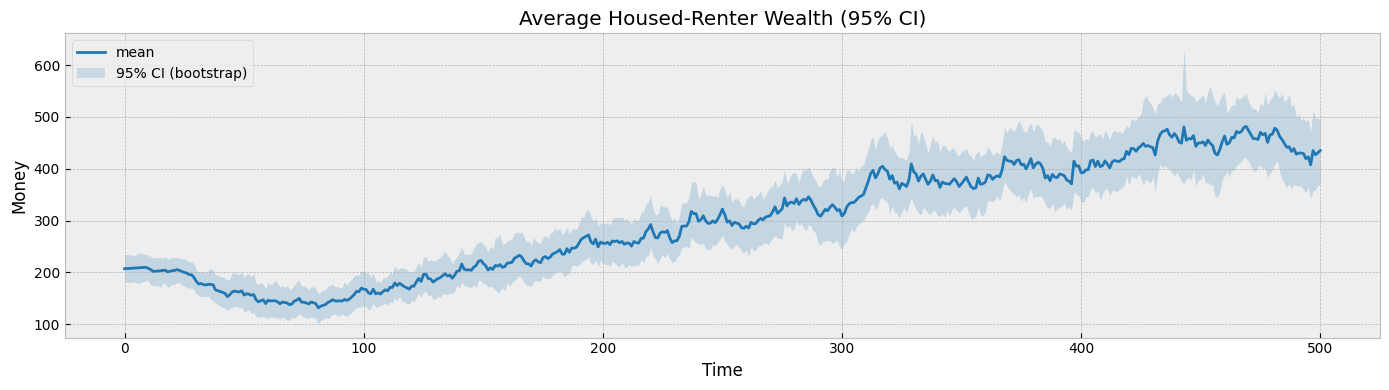

(<Figure size 1400x400 with 1 Axes>,
 <Axes: title={'center': 'Average Housed-Renter Wealth (95% CI)'}, xlabel='Time', ylabel='Money'>)

In [ ]:
viz.plot_housed_renter_wealth()

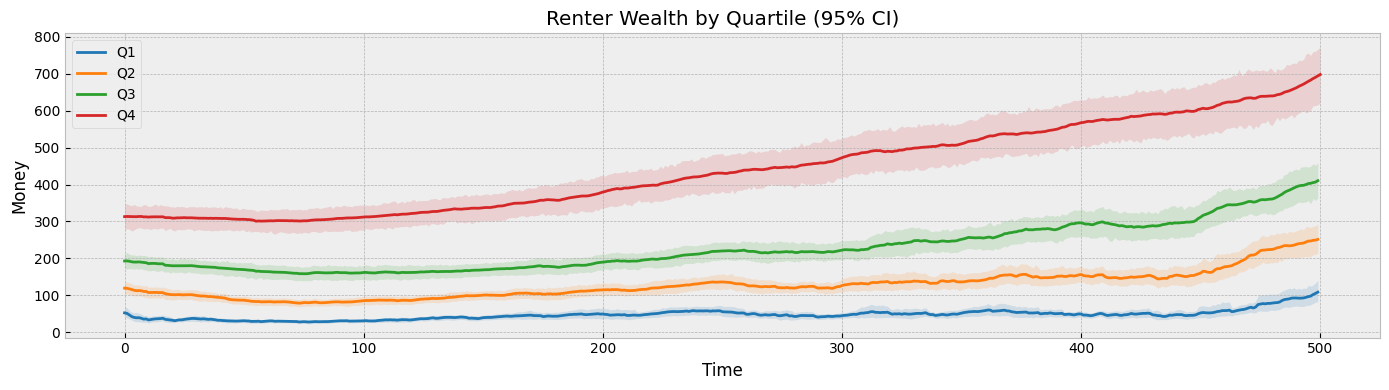

(<Figure size 1400x400 with 1 Axes>,
 <Axes: title={'center': 'Renter Wealth by Quartile (95% CI)'}, xlabel='Time', ylabel='Money'>)

In [ ]:
viz.plot_wealth_quartiles()

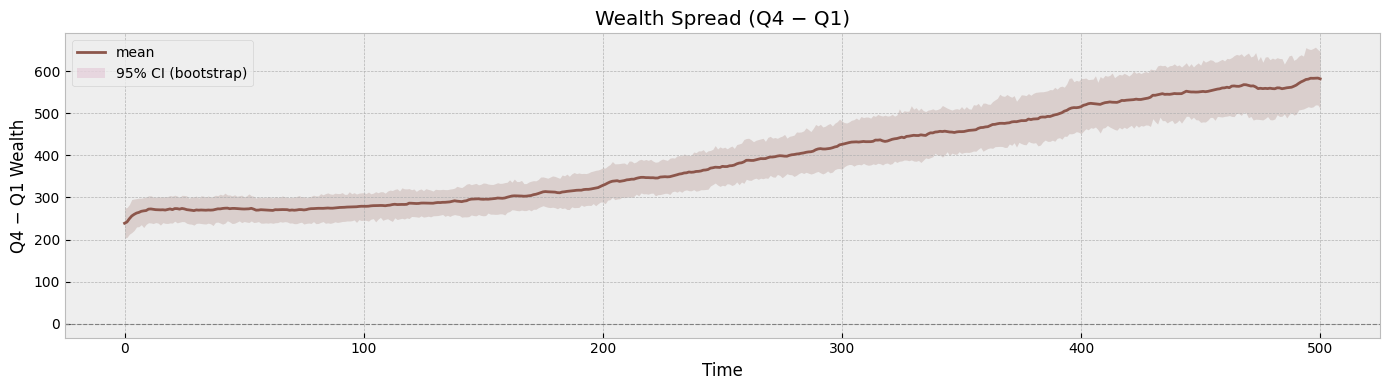

(<Figure size 1400x400 with 1 Axes>,
 <Axes: title={'center': 'Wealth Spread (Q4 − Q1)'}, xlabel='Time', ylabel='Q4 − Q1 Wealth'>)

In [ ]:
viz.plot_wealth_spread()

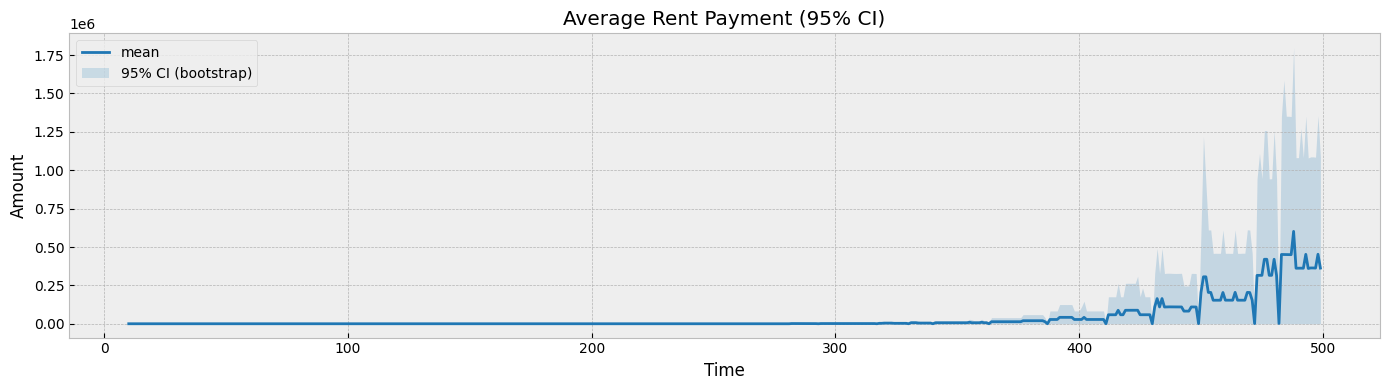

(<Figure size 1400x400 with 1 Axes>,
 <Axes: title={'center': 'Average Rent Payment (95% CI)'}, xlabel='Time', ylabel='Amount'>)

In [ ]:
viz.plot_avg_rent()

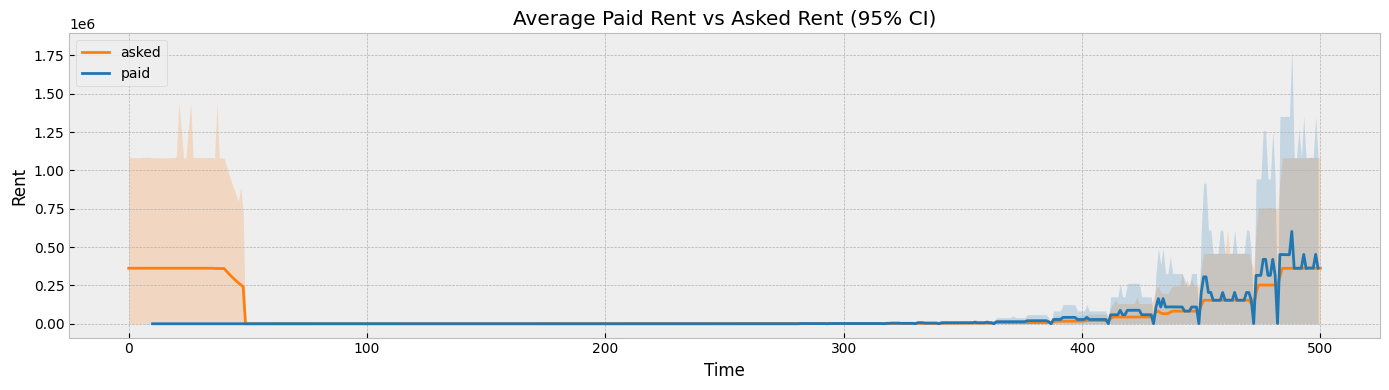

(<Figure size 1400x400 with 1 Axes>,
 <Axes: title={'center': 'Average Paid Rent vs Asked Rent (95% CI)'}, xlabel='Time', ylabel='Rent'>)

In [ ]:
viz.plot_paid_vs_asked()

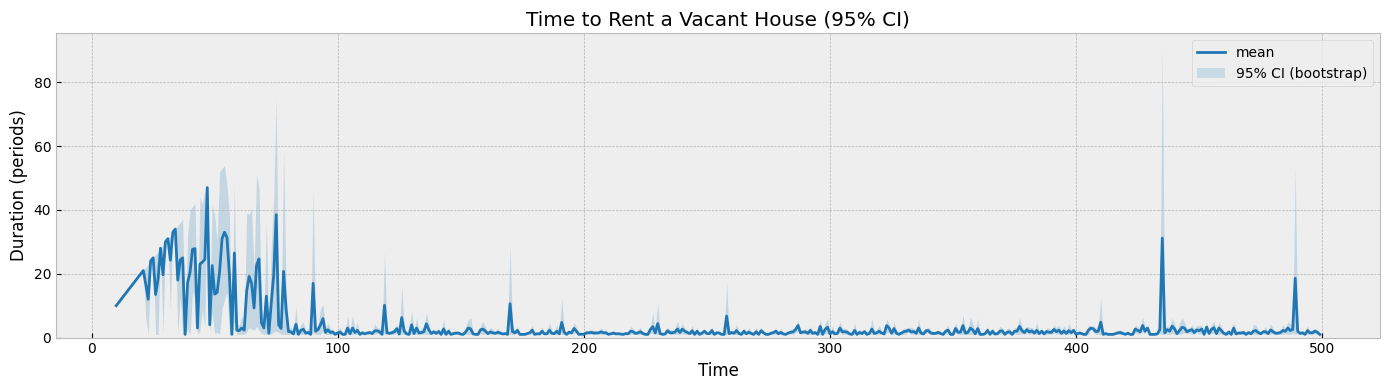

(<Figure size 1400x400 with 1 Axes>,
 <Axes: title={'center': 'Time to Rent a Vacant House (95% CI)'}, xlabel='Time', ylabel='Duration (periods)'>)

In [ ]:
viz.plot_time_to_rent()

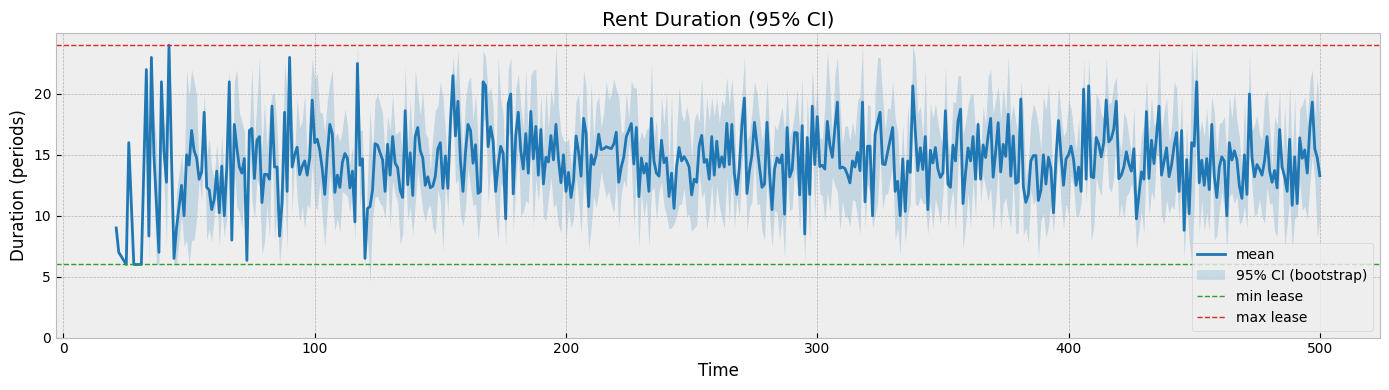

(<Figure size 1400x400 with 1 Axes>,
 <Axes: title={'center': 'Rent Duration (95% CI)'}, xlabel='Time', ylabel='Duration (periods)'>)

In [ ]:
viz.plot_rent_duration()

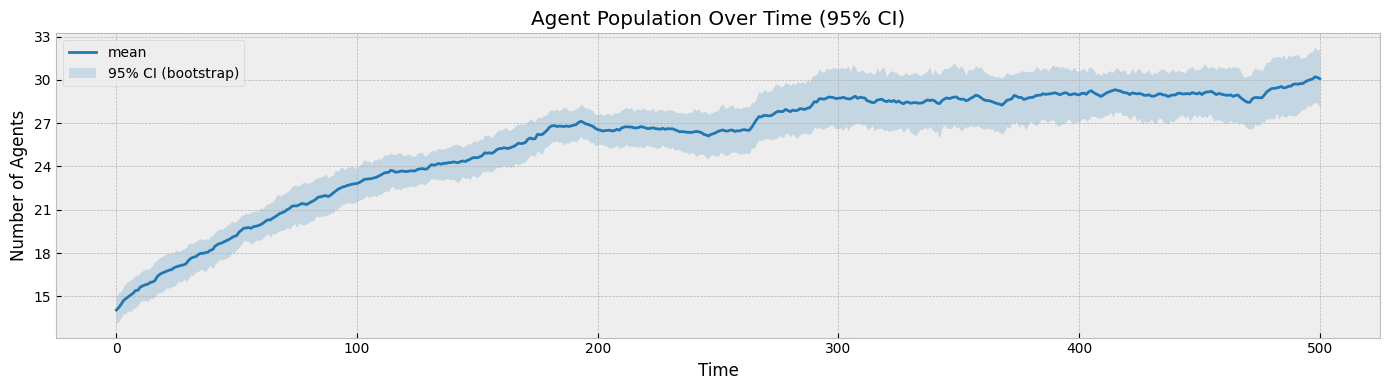

(<Figure size 1400x400 with 1 Axes>,
 <Axes: title={'center': 'Agent Population Over Time (95% CI)'}, xlabel='Time', ylabel='Number of Agents'>)

In [ ]:
viz.plot_population()